# HW 16 - PyTorch
ULAB - Physics and Astronomy Division \
Due **Sunday, March 16th, 2025 at 11:59pm** on Gradescope

**Make sure to work on this notebook in DataHub!**

# 1) Recap of lecture
**Copy and paste** your code from lecture for the neural network with the **default** settings (i.e. before we improved the model). Make sure to also import the `data.py` file. 

In [2]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpuNote: you may need to restart the kernel to use updated packages.

     ---------------------------------------- 0.0/6.2 MB ? eta -:--:--
     ---- ----------------------------------- 0.6/6.2 MB 10.1 MB/s eta 0:00:01
     ------ --------------------------------- 1.0/6.2 MB 10.8 MB/s eta 0:00:01
     --------- ------------------------------ 1.5/6.2 MB 10.9 MB/s eta 0:00:01
     ------------ --------------------------- 2.0/6.2 MB 10.5 MB/s eta 0:00:01
     ---------------- ----------------------- 2.5/6.2 MB 10.5 MB/s eta 0:00:01
     ------------------- -------------------- 3.0/6.2 MB 10.6 MB/s eta 0:00:01
     ---------------------- ----------------- 3.6/6.2 MB 10.8 MB/s eta 0:00:01
     -------------------------- ------------- 4.1/6.2 MB 11.0 MB/s eta 0:00:01
     ------------------------------ --------- 4.8/6.2 MB 11.3 MB/s eta 0:00:01
     ---------------------------------- ----- 5.4/6.2 MB 11.4 MB/s eta 0:00:01
     -----------

In [1]:
import data
import matplotlib.pyplot as plt
import torch

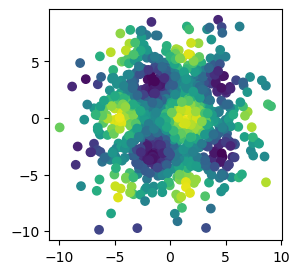

In [2]:
plt.figure(figsize = (3, 3))
plt.scatter(data.x_values, data.y_values, c=data.color_values)
plt.show()

In [3]:
model = torch.nn.Sequential(
    torch.nn.Linear(2, 50),
    torch.nn.Sigmoid(),
    torch.nn.Linear(50, 1)
)

In [13]:
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)

In [5]:
for t in range(1000):
    y_pred = model(data.x)
    loss = loss_fn(y_pred, data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

C:\Users\macka\anaconda3\Lib\site-packages\torch\functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:3638.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


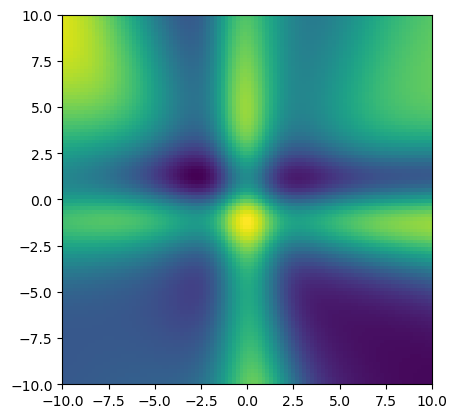

In [6]:
new_x = torch.linspace(-10, 10, 100)
grid = torch.stack(torch.meshgrid((new_x, new_x)), dim = 2)

output = model(grid).detach()
plt.imshow(output, extent = (-10, 10, -10, 10))
plt.show()

What is the difference between artificial intelligence, machine learning and deep learning?

In [7]:
# Artificial intelligence is the blanket term, machine learning builds a model and makes predicitions, while deep learning i ssimilar an used for more complex problems.

What is a neural network?

In [8]:
# It teachers computers to process data akin to a human.

In lecture, we used `torch.nn.Linear(2, 50)`. What do the numbers `2` and `50` represent? 

In [9]:
# 2 in number of input features and 50 is number of output features. 

What does the activation function do?

In [10]:
# It adds non-linearity to the neural network solution. 

What is a loss function? Why do we need one?

In [11]:
# The loss function measures the prediction to the data's actual value, and it is needed to provide feedback to the neural network.

Why do we call `optimizer.zero_grad()` before calling `loss.backward()`?

In [12]:
# Optimizer is called before loss so the gradient is reset the model before creating a new one.

# 2) Modifying the Neural Network
What line do you need to modify to use **30 neurons** instead of **50**? Don't change anything else. Give the original and then modified line. 

In [13]:
model = torch.nn.Sequential(
    torch.nn.Linear(2, 30),
    torch.nn.Sigmoid(),
    torch.nn.Linear(30, 1)
)

In [14]:
for t in range(1000):
    y_pred = model(data.x)
    loss = loss_fn(y_pred, data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

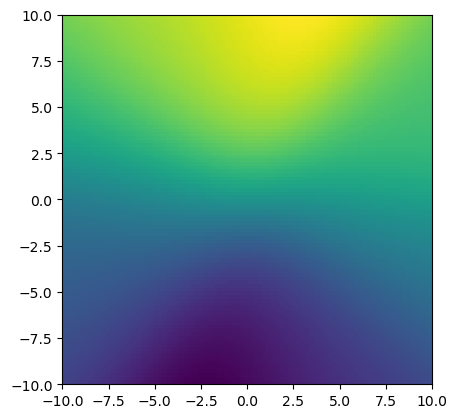

In [15]:
new_x = torch.linspace(-10, 10, 100)
grid = torch.stack(torch.meshgrid((new_x, new_x)), dim = 2)

output = model(grid).detach()
plt.imshow(output, extent = (-10, 10, -10, 10))
plt.show()

With your default code above, run your model with **30 neurons**. Compare the loss functions from lecture to your modification on the **1000th** iteration. 

In [16]:
# It's significantly worse with it having no pattern resembling the data.

Return to **50 neurons**. Change your activation function from `torch.nn.Sigmoid()` to `torch.nn.ReLU`. Compare the loss functions from lecture to your modification on the **1000th** iteration. 

In [17]:
model = torch.nn.Sequential(
    torch.nn.Linear(2, 50),
    torch.nn.ReLU(),
    torch.nn.Linear(50, 1)
)

In [18]:
for t in range(1000):
    y_pred = model(data.x)
    loss = loss_fn(y_pred, data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

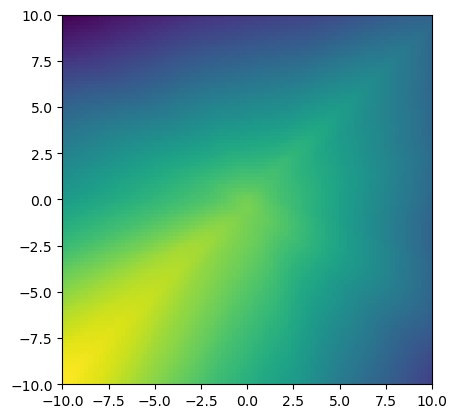

In [19]:
new_x = torch.linspace(-10, 10, 100)
grid = torch.stack(torch.meshgrid((new_x, new_x)), dim = 2)

output = model(grid).detach()
plt.imshow(output, extent = (-10, 10, -10, 10))
plt.show()

In [5]:
# It is still bad.

Change your activation function from `torch.nn.Sigmoid()` to `torch.nn.Tanh`? Compare the loss functions from lecture to your modification on the **1000th** iteration. 

In [21]:
model = torch.nn.Sequential(
    torch.nn.Linear(2, 50),
    torch.nn.Tanh(),
    torch.nn.Linear(50, 1)
)

In [22]:
for t in range(1000):
    y_pred = model(data.x)
    loss = loss_fn(y_pred, data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

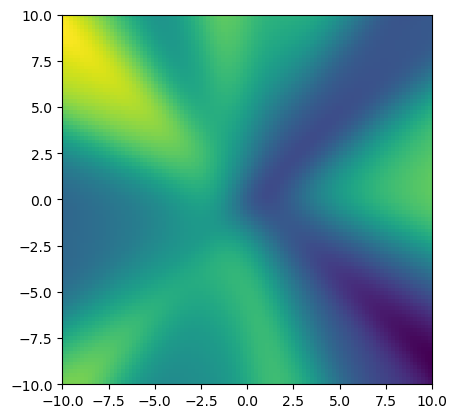

In [23]:
new_x = torch.linspace(-10, 10, 100)
grid = torch.stack(torch.meshgrid((new_x, new_x)), dim = 2)

output = model(grid).detach()
plt.imshow(output, extent = (-10, 10, -10, 10))
plt.show()

In [24]:
# The colors are not as abd and it can be seen resembling what the data shows but it still isn't as good.

What is the difference between `torch.nn.Sigmoid()`, `torch.nn.ReLU` and `torch.nn.Tanh`? 

In [25]:
# Sigmoid is between 0 and 1, ReLu is between 0 and infinity, and Tanh is between -1 and 1.

Return to `torch.nn.Sigmoid()`. Change your learning rate from `1e-3` to `1e-2` in your optimizer. Compare the loss functions from lecture to your modification on the **1000th** iteration. 

In [26]:
model = torch.nn.Sequential(
    torch.nn.Linear(2, 50),
    torch.nn.Sigmoid(),
    torch.nn.Linear(50, 1)
)

In [27]:
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-2)

In [28]:
for t in range(1000):
    y_pred = model(data.x)
    loss = loss_fn(y_pred, data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

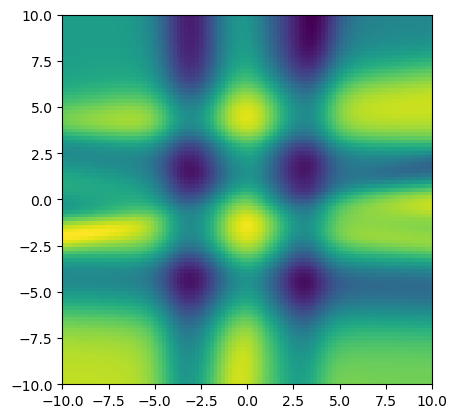

In [29]:
new_x = torch.linspace(-10, 10, 100)
grid = torch.stack(torch.meshgrid((new_x, new_x)), dim = 2)

output = model(grid).detach()
plt.imshow(output, extent = (-10, 10, -10, 10))
plt.show()

In [30]:
# The most accurate one out of everything tried so far.

Modify your model to have **two hidden layers** instead of one. Give that code here.

In [31]:
model = torch.nn.Sequential(
    torch.nn.Linear(2, 50),  
    torch.nn.Sigmoid(),      
    torch.nn.Linear(50, 50), 
    torch.nn.Sigmoid(),      
    torch.nn.Linear(50, 1)   
)

In [32]:
for t in range(1000):
    y_pred = model(data.x)
    loss = loss_fn(y_pred, data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

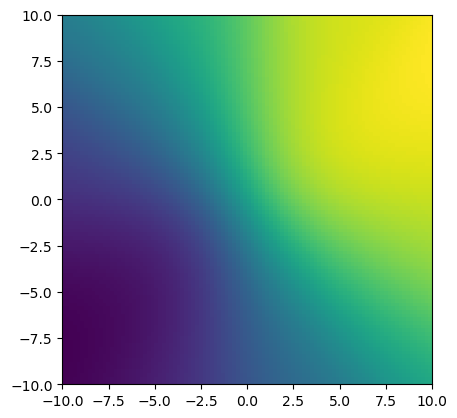

In [33]:
new_x = torch.linspace(-10, 10, 100)
grid = torch.stack(torch.meshgrid((new_x, new_x)), dim = 2)

output = model(grid).detach()
plt.imshow(output, extent = (-10, 10, -10, 10))
plt.show()

# 3) More Advanced
Create a new file called `new_data.py`, make a new "hidden" function and add noise/ obscure the data (e.g. like what is done in `data.py` from lecture). Import that file here.

In [2]:
import new_data

Define a new model and train it **poorly** in the cell below.

In [42]:
model = torch.nn.Sequential(
    torch.nn.Linear(2, 30), 
    torch.nn.ReLU(), 
    torch.nn.Linear(30, 1) 
)

In [43]:
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-10)

In [44]:
for t in range(1000):
    y_pred = model(new_data.x)
    loss = loss_fn(y_pred, new_data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

In [45]:
new_x = torch.linspace(-10, 10, 100)
grid = torch.stack(torch.meshgrid((new_x, new_x)), dim = 2)

poor_output = model(grid).detach()

In [33]:
model = torch.nn.Sequential(
    torch.nn.Linear(2, 100), 
    torch.nn.Sigmoid(), 
    torch.nn.Linear(100, 1) 
)

In [34]:
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-2)

In [35]:
for t in range(1000):
    y_pred = model(new_data.x)
    loss = loss_fn(y_pred, new_data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

In [39]:
new_x = torch.linspace(-10, 10, 100)
grid = torch.stack(torch.meshgrid((new_x, new_x)), dim = 2)

output = model(grid).detach()

Improve your model and train it **well** in the cell below. (You can add more neurons, iterations, etc).

Make foure subplots (two rows, two columns). 
- (TOP LEFT) Show what the "hidden pattern" is supposed to be.
- (TOP RIGHT) Show that your "data" is.
- (BOTTOM LEFT) Show your model's prediction when you trained it poorly.
- (BOTTOM RIGHT) Show your model's prediction when you trained it well.

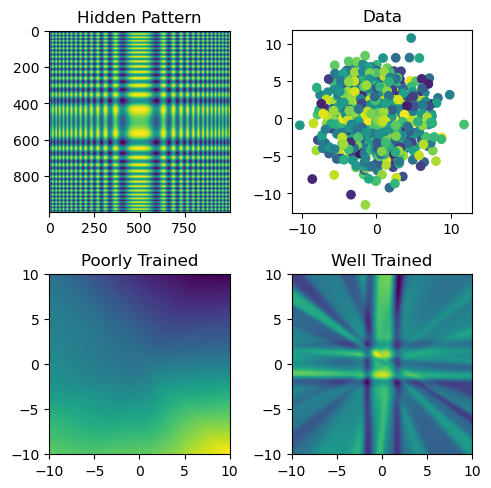

In [46]:
fig, axs = plt.subplots(2, 2, figsize = (5, 5))

axs[0, 0].imshow(new_data.pattern)
axs[0, 0].set_title('Hidden Pattern')

axs[0, 1].scatter(new_data.x_values, new_data.y_values, c=new_data.color_values)
axs[0, 1].set_title('Data')

axs[1, 0].imshow(poor_output, extent = (-10, 10, -10, 10))
axs[1, 0].set_title('Poorly Trained')

axs[1, 1].imshow(output, extent = (-10, 10, -10, 10))
axs[1, 1].set_title('Well Trained')

plt.tight_layout()
plt.show()

# 4) Challenge
Find some data online and build a neural network around it. Make sure to also answer these questions:
- Where did you find your data? 
- How well does your model match your data?

In [4]:
import pandas as pd
df = pd.read_csv('worldcities.csv')

In [5]:
df = df.dropna()

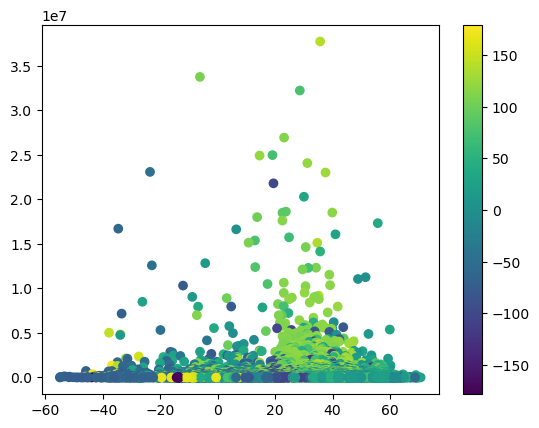

In [6]:
plt.scatter(df['lat'], df['population'], c = df['lng'])
plt.colorbar()
plt.show()

In [36]:
model = torch.nn.Sequential(
    torch.nn.Linear(2, 200), 
    torch.nn.Tanh(), 
    torch.nn.Linear(200, 200), 
    torch.nn.Tanh(),
    torch.nn.Linear(200, 1) 
)

In [10]:
X, Y = np.meshgrid(df['lat'], df['population'])
pattern = np.cos(X**2) + np.sin(Y**2)
N, D_in, H, D_out = 1000, 2, 50, 1

x = torch.randn(N, D_in) * 3.1415
y = ((x**2)[:, 0].sin() + (x**2)[:, 1].cos()).unsqueeze(1)

noise = torch.randn(N, D_out) * 0.1 
y += noise  

x_values = x.numpy()[:, 0]
y_values = x.numpy()[:, 1]
color_values = y.numpy().flatten()

In [37]:
for t in range(10000):
    y_pred = model(x)
    loss = loss_fn(y_pred, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

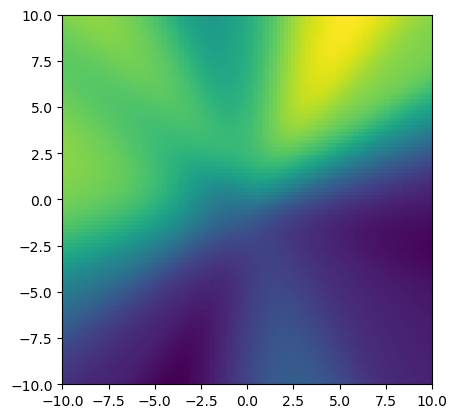

In [38]:
new_x = torch.linspace(-10, 10, 100)
grid = torch.stack(torch.meshgrid((new_x, new_x)), dim = 2)

output = model(grid).detach()
plt.imshow(output, extent = (-10, 10, -10, 10))
plt.show()

In [39]:
# I found my data on https://simplemaps.com/data/world-cities.
# It isn't the greatets given the provied dataset is clumped together and not spread out.

Once you are done, make sure to:
- Download this notebook and all releveant files (`new_data.py`, stuff from question 4, etc) from datahub.
- Move it to your **remote repository**.
- Upload to Gradescope!